# CNN for MNIST Digit Classification

In [1]:
"""
Convolutional Neural Network (CNN) for MNIST Digit Classification.

This notebook demonstrates a full pipeline for training a basic CNN on the MNIST dataset using TensorFlow/Keras.
It includes data preprocessing, model architecture, training with early stopping, and evaluation using classification metrics.

Key Components:
- Dataset: MNIST (28x28 grayscale images of handwritten digits 0–9)
- Model: Sequential CNN with Conv2D, MaxPooling, Flatten, and Dense layers
- Optimization: Adam optimizer with categorical crossentropy loss
- Evaluation: Accuracy, classification report, and confusion matrix

Intended for educational and baseline benchmarking use cases.
"""


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

# GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

# Threading config
tf.config.threading.set_intra_op_parallelism_threads(32)
tf.config.threading.set_inter_op_parallelism_threads(32)


2025-05-02 22:44:08.530000: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-02 22:44:08.538199: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746251048.547501  914452 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746251048.550319  914452 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746251048.557978  914452 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

GPU memory growth enabled


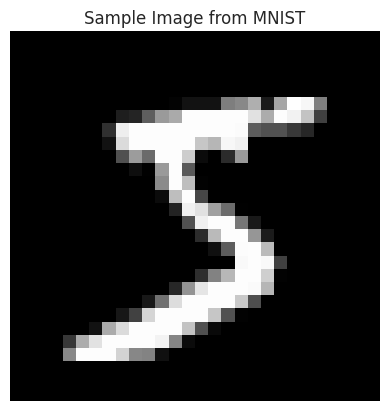

In [2]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

plt.imshow(x_train[0], cmap='gray')
plt.title("Sample Image from MNIST")
plt.axis('off')
plt.show()


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_cat_train = to_categorical(y_train, 10)
y_cat_test = to_categorical(y_test, 10)


In [4]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, kernel_size=(4, 4), activation='relu'),
    MaxPool2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


I0000 00:00:1746251049.901118  914452 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21615 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6


In [5]:
early_stop = EarlyStopping(monitor='val_loss', patience=1)

history = model.fit(
    x_train, y_cat_train,
    validation_data=(x_test, y_cat_test),
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10


I0000 00:00:1746251050.842413  914614 service.cc:152] XLA service 0x7065a4017280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746251050.842425  914614 service.cc:160]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2025-05-02 22:44:10.854525: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1746251050.914430  914614 cuda_dnn.cc:529] Loaded cuDNN version 90800
2025-05-02 22:44:11.344340: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_200', 4 bytes spill stores, 4 bytes spill loads



 207/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step - accuracy: 0.7539 - loss: 0.8129

I0000 00:00:1746251051.924516  914614 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9149 - loss: 0.2832 - val_accuracy: 0.9796 - val_loss: 0.0638
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 847us/step - accuracy: 0.9844 - loss: 0.0499 - val_accuracy: 0.9855 - val_loss: 0.0442
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 835us/step - accuracy: 0.9898 - loss: 0.0317 - val_accuracy: 0.9875 - val_loss: 0.0382
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 788us/step - accuracy: 0.9938 - loss: 0.0187 - val_accuracy: 0.9880 - val_loss: 0.0366
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - accuracy: 0.9964 - loss: 0.0115 - val_accuracy: 0.9895 - val_loss: 0.0382


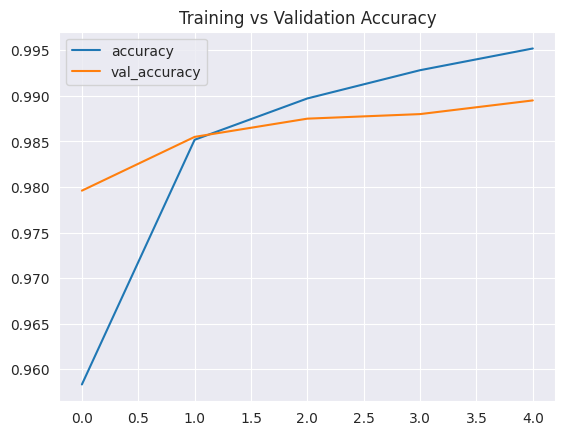

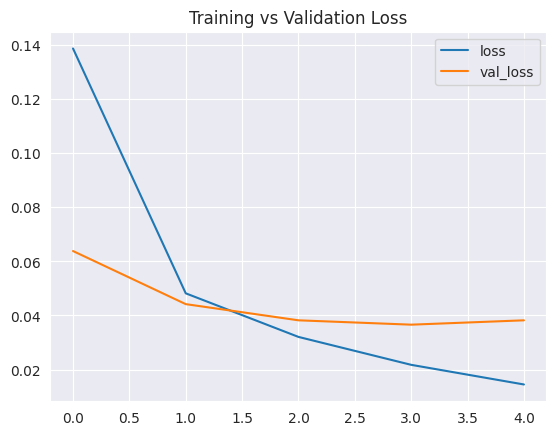

In [6]:
metrics = pd.DataFrame(history.history)

metrics[['accuracy', 'val_accuracy']].plot(title="Training vs Validation Accuracy")
plt.show()

metrics[['loss', 'val_loss']].plot(title="Training vs Validation Loss")
plt.show()


In [7]:
predictions = model.predict(x_test)
pred_labels = np.argmax(predictions, axis=1)

print(classification_report(y_test, pred_labels))


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.98      0.99       958
           7       1.00      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



Confusion Matrix (Raw):
[[ 975    0    2    1    0    0    0    0    1    1]
 [   1 1128    1    1    1    0    1    1    1    0]
 [   1    0 1025    1    0    0    2    3    0    0]
 [   0    0    1  999    0    6    0    0    4    0]
 [   1    0    2    0  971    0    1    0    1    6]
 [   1    0    1    2    0  886    1    0    1    0]
 [   6    1    1    1    2    3  941    0    3    0]
 [   1    1   11    0    0    1    0 1008    1    5]
 [   4    1    2    1    0    0    0    0  964    2]
 [   0    1    1    0    5    3    0    1    0  998]]


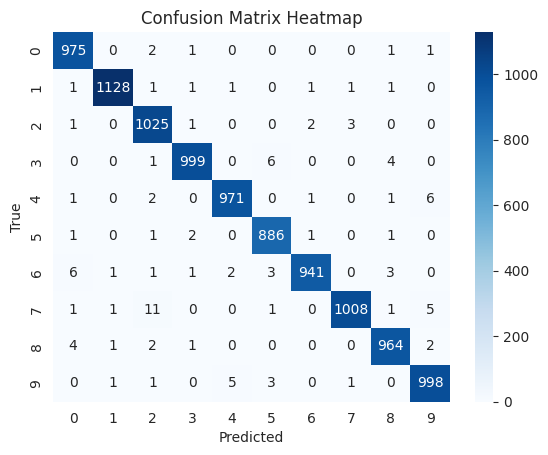

In [8]:
conf_mat = confusion_matrix(y_test, pred_labels)
print("Confusion Matrix (Raw):")
print(conf_mat)

sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
